In [1]:
# =============================================================================
# 🧹 NETTOYAGE SYSTÈME (SSH) - EXÉCUTER EN PREMIER!
# =============================================================================

import os, gc, shutil, glob

def quick_cleanup():
    """Nettoyage rapide avant exécution."""
    print("🧹 NETTOYAGE...")
    gc.collect()
    
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem = torch.cuda.memory_allocated() / 1e9
            print(f"✅ CUDA: {mem:.2f} GB alloué")
    except: pass
    
    for pattern in ['**/__pycache__', '**/.ipynb_checkpoints']:
        for p in glob.glob(pattern, recursive=True):
            try: shutil.rmtree(p)
            except: pass
    
    total, used, free = shutil.disk_usage('/')
    print(f"💾 Espace: {free/1e9:.1f} GB libre")
    print("✅ Prêt!")

quick_cleanup()

🧹 NETTOYAGE...
✅ CUDA: 0.00 GB alloué
💾 Espace: 2.9 GB libre
✅ Prêt!


In [2]:
# =============================================================================
# 📦 IMPORTS & CONFIGURATION
# =============================================================================
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import joblib

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')
print(f'🔢 PyTorch version: {torch.__version__}')

🖥️ Device: cuda
🔢 PyTorch version: 2.8.0+cu128


## 📥 1. Chargement des Données

In [3]:
# =============================================================================
# 📂 PATHS CONFIGURATION - CORRIGÉS pour fichiers existants
# =============================================================================
DATA_DIR = './data'
EMB_DIR = os.path.join(DATA_DIR, 'embeddings')

# File paths - FICHIERS RÉELLEMENT EXISTANTS
paths = {
    # Embeddings CamemBERT (768d ou 2304d multi-layer)
    'train_embeddings': os.path.join(EMB_DIR, 'X_train_text_embeddings.npy'),
    'kaggle_embeddings': os.path.join(EMB_DIR, 'X_kaggle_text_embeddings.npy'),
    # Ou multi-layer (meilleur)
    'train_embeddings_ml': os.path.join(EMB_DIR, 'X_train_multilayer_embeddings.npy'),
    'kaggle_embeddings_ml': os.path.join(EMB_DIR, 'X_kaggle_multilayer_embeddings.npy'),
    # Features structurées (CSV de feature_engineering.ipynb)
    'train_features': os.path.join(DATA_DIR, 'train_features.csv'),
    'kaggle_features': os.path.join(DATA_DIR, 'test_features.csv'),
    # Labels
    'y_train': os.path.join(DATA_DIR, 'y_train.npy'),
}

# Check files exist
for name, path in paths.items():
    if os.path.exists(path):
        print(f"✅ {name}: {path}")
    else:
        print(f"❌ {name}: {path} - MANQUANT")

❌ train_embeddings: ./data/embeddings/X_train_text_embeddings.npy - MANQUANT
❌ kaggle_embeddings: ./data/embeddings/X_kaggle_text_embeddings.npy - MANQUANT
✅ train_embeddings_ml: ./data/embeddings/X_train_multilayer_embeddings.npy
✅ kaggle_embeddings_ml: ./data/embeddings/X_kaggle_multilayer_embeddings.npy
✅ train_features: ./data/train_features.csv
✅ kaggle_features: ./data/test_features.csv
✅ y_train: ./data/y_train.npy


In [4]:
# =============================================================================
# 📊 LOAD DATA - Utilise les fichiers réels
# =============================================================================
def clean_array(arr):
    """Clean NaN/inf values and convert to float32."""
    arr = np.asarray(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    return arr.astype(np.float32)

# Load embeddings (utiliser multi-layer si disponible, sinon standard)
USE_MULTILAYER = os.path.exists(paths['train_embeddings_ml'])
if USE_MULTILAYER:
    X_train_emb = clean_array(np.load(paths['train_embeddings_ml']))
    X_kaggle_emb = clean_array(np.load(paths['kaggle_embeddings_ml']))
    print(f"📊 Using MULTILAYER embeddings (2304d)")
else:
    X_train_emb = clean_array(np.load(paths['train_embeddings']))
    X_kaggle_emb = clean_array(np.load(paths['kaggle_embeddings']))
    print(f"📊 Using standard embeddings (768d)")

# Load structured features from CSV (feature_engineering.ipynb output)
train_df = pd.read_csv(paths['train_features'])
kaggle_df = pd.read_csv(paths['kaggle_features'])

# ⭐ Features numériques les plus importantes (basées sur LightGBM feature importance)
# Ordonnées par importance décroissante selon feature_engineering.ipynb
TOP_FEATURES = [
    # TOP 6 features (importance > 500)
    'user_description_length',   # importance=736 ⭐
    'tweets_per_favourites',     # importance=699 ⭐
    'user_favourites_count',     # importance=646 ⭐
    'user_statuses_count',       # importance=639 ⭐
    'user_listed_count',         # importance=607 ⭐
    'listed_per_status',         # importance=553 ⭐
    # Log transforms (haute corrélation)
    'log_user_listed',           # corr=0.606 ⭐
    'log_user_statuses',         # corr=0.439
    'log_user_favourites',
    # Engagement features
    'total_engagement', 'log_total_engagement',
    'retweet_count', 'favorite_count', 'reply_count', 'quote_count',
    'log_retweet_count', 'log_favorite_count',
    # Binary user features (très discriminantes)
    'user_has_url',              # Observer=16%, Influencer=56%
    'user_has_banner',           # Observer=73%, Influencer=92%
    'user_has_location',         # Observer=58%, Influencer=75%
    'user_has_long_desc',
    'user_default_profile', 'user_default_profile_image',
    # Source device (très discriminant)
    'is_iphone', 'is_android', 'is_web', 'is_tweetdeck', 'is_bot_source',
    # Text features
    'tweet_length', 'word_count', 'uppercase_ratio',
    'hashtag_count', 'is_hashtag_heavy',
    'mention_count', 'is_mention_heavy',
    'emoji_count', 'is_emoji_heavy',
    'exclamation_count', 'question_count', 'has_multiple_exclamations',
    'url_count', 'has_url',
    # Content detection
    'is_reply', 'is_in_reply', 'is_reply_to_someone',
    'has_rt_qt', 'is_quote_status', 'has_quoted_status',
    'has_call_to_action', 'has_self_promotion', 'has_media_reference',
    # Entities
    'entities_hashtags', 'entities_urls', 'entities_mentions', 'entities_symbols',
    # Other
    'first_person_count', 'is_long_tweet', 'is_short_tweet'
]

# Filter to features that exist
available_features = [f for f in TOP_FEATURES if f in train_df.columns]
print(f"📊 Using {len(available_features)} structured features")

# Extract and clean features
X_train_feat = clean_array(train_df[available_features].fillna(0).values)
X_kaggle_feat = clean_array(kaggle_df[available_features].fillna(0).values)

# Normalize features
from sklearn.preprocessing import StandardScaler
feat_scaler = StandardScaler()
X_train_feat = feat_scaler.fit_transform(X_train_feat)
X_kaggle_feat = feat_scaler.transform(X_kaggle_feat)

# Load labels
y_full = np.load(paths['y_train'])
le = LabelEncoder()
y_full = le.fit_transform(y_full)

print(f"\n📊 Data Shapes:")
print(f"   Embeddings (train): {X_train_emb.shape}")
print(f"   Structured features (train): {X_train_feat.shape}")
print(f"   Labels: {y_full.shape}, Classes: {np.unique(y_full)}")
print(f"   Class distribution: {np.bincount(y_full)}")

📊 Using MULTILAYER embeddings (2304d)
📊 Using 40 structured features

📊 Data Shapes:
   Embeddings (train): (154914, 6144)
   Structured features (train): (154914, 40)
   Labels: (154914,), Classes: [0 1]
   Class distribution: [82674 72240]


## 🔧 2. Feature Engineering Avancé

Inspiré de Lab6 - Création de features combinées et interactions.

In [5]:
# =============================================================================
# 🔧 COMBINE EMBEDDINGS + FEATURES
# =============================================================================

# Combine: embeddings + structured features
X_train_combined = np.hstack([X_train_emb, X_train_feat])
X_kaggle_combined = np.hstack([X_kaggle_emb, X_kaggle_feat])

print(f"📊 Combined features:")
print(f"   Train: {X_train_combined.shape}")
print(f"   Kaggle: {X_kaggle_combined.shape}")

# Calculate dimensions for the neural network
EMB_DIM = X_train_emb.shape[1]
FEAT_DIM = X_train_feat.shape[1]
TOTAL_DIM = X_train_combined.shape[1]

print(f"\n🔢 Dimensions:")
print(f"   Embedding dim: {EMB_DIM}")
print(f"   Feature dim: {FEAT_DIM}")
print(f"   Total dim: {TOTAL_DIM}")

📊 Combined features:
   Train: (154914, 6184)
   Kaggle: (103380, 6184)

🔢 Dimensions:
   Embedding dim: 6144
   Feature dim: 40
   Total dim: 6184


In [6]:
# =============================================================================
# 📊 TRAIN/VAL SPLIT
# =============================================================================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_combined, y_full, 
    test_size=0.15, 
    random_state=SEED, 
    stratify=y_full
)

# Also split embeddings and features separately for multi-branch model
X_train_emb_split, X_val_emb_split = train_test_split(
    X_train_emb, test_size=0.15, random_state=SEED, stratify=y_full
)
X_train_feat_split, X_val_feat_split = train_test_split(
    X_train_feat, test_size=0.15, random_state=SEED, stratify=y_full
)

print(f"📊 Train/Val split:")
print(f"   Train: {X_train.shape}, Labels: {np.bincount(y_train)}")
print(f"   Val: {X_val.shape}, Labels: {np.bincount(y_val)}")

📊 Train/Val split:
   Train: (131676, 6184), Labels: [70272 61404]
   Val: (23238, 6184), Labels: [12402 10836]


## ⚙️ Configuration : Entraînement ou Chargement des Modèles

Configure ici quels modèles tu veux entraîner ou charger depuis les checkpoints sauvegardés.


In [7]:
# =============================================================================
# ⚙️ CONFIGURATION : CHOISIR QUELS MODÈLES ENTRAÎNER
# =============================================================================

# 🎯 Configure ici ce que tu veux faire
TRAIN_NEURAL_NETWORK = True   # Set to True pour réentraîner le NN
TRAIN_XGBOOST = False          # Set to False pour charger depuis fichier
TRAIN_LIGHTGBM = False         # Set to False pour charger depuis fichier

# Chemins des modèles sauvegardés
MODEL_DIR = 'models'
XGBOOST_PATH = os.path.join(MODEL_DIR, 'xgb_model.joblib')
LIGHTGBM_PATH = os.path.join(MODEL_DIR, 'lgbm_model.joblib')
SCALER_PATH = os.path.join(MODEL_DIR, 'scaler.joblib')
NN_PATH = os.path.join(MODEL_DIR, 'influencer_model_simple.pt')

print("⚙️ Training Configuration:")
print(f"   Neural Network: {'🔄 TRAIN' if TRAIN_NEURAL_NETWORK else '📂 LOAD'}")
print(f"   XGBoost: {'🔄 TRAIN' if TRAIN_XGBOOST else '📂 LOAD'}")
print(f"   LightGBM: {'🔄 TRAIN' if TRAIN_LIGHTGBM else '📂 LOAD'}")

# Vérifier quels modèles existent
print("\n📁 Checking saved models...")
print(f"   XGBoost: {'✅ Found' if os.path.exists(XGBOOST_PATH) else '❌ Not found'}")
print(f"   LightGBM: {'✅ Found' if os.path.exists(LIGHTGBM_PATH) else '❌ Not found'}")
print(f"   Scaler: {'✅ Found' if os.path.exists(SCALER_PATH) else '❌ Not found'}")
print(f"   Neural Network: {'✅ Found' if os.path.exists(NN_PATH) else '❌ Not found'}")

# Avertissements si besoin
if not TRAIN_XGBOOST and not os.path.exists(XGBOOST_PATH):
    print("\n⚠️ WARNING: XGBoost set to LOAD but file not found! Will train instead.")
    TRAIN_XGBOOST = True

if not TRAIN_LIGHTGBM and not os.path.exists(LIGHTGBM_PATH):
    print("\n⚠️ WARNING: LightGBM set to LOAD but file not found! Will train instead.")
    TRAIN_LIGHTGBM = True

if (not TRAIN_XGBOOST or not TRAIN_LIGHTGBM) and not os.path.exists(SCALER_PATH):
    print("\n⚠️ WARNING: Scaler not found but needed for boosting models!")
    print("   Will create new scaler - make sure to retrain boosting models!")
    TRAIN_XGBOOST = True
    TRAIN_LIGHTGBM = True


⚙️ Training Configuration:
   Neural Network: 🔄 TRAIN
   XGBoost: 📂 LOAD
   LightGBM: 📂 LOAD

📁 Checking saved models...
   XGBoost: ✅ Found
   LightGBM: ✅ Found
   Scaler: ✅ Found
   Neural Network: ✅ Found


## ✅ Système de chargement configuré!

Le système de chargement/entraînement sélectif est maintenant en place dans **Cell 21**.

**Cell 21** va automatiquement:
- ✅ Charger XGBoost/LightGBM depuis `models/` si les flags sont `False`
- ✅ Les entraîner si les flags sont `True`
- ✅ Gérer le scaler automatiquement

**Prêt à utiliser!** Configure les flags dans Cell 9 et run le notebook normalement.


## 🎯 GUIDE D'UTILISATION : Réentraîner uniquement le NN

### Scénario 1: Tout entraîner depuis le début
```python
TRAIN_NEURAL_NETWORK = True
TRAIN_XGBOOST = True  
TRAIN_LIGHTGBM = True
```
Run toutes les cellules normalement.

### Scénario 2: Réentraîner uniquement le Neural Network ⭐
```python
TRAIN_NEURAL_NETWORK = True   # Réentraîner le NN
TRAIN_XGBOOST = False          # Charger depuis fichier
TRAIN_LIGHTGBM = False         # Charger depuis fichier
```

**Workflow:**
1. Run **Cell 9** (Configuration) - définit ce qu'on charge/entraîne
2. Run **Cell 19** (modifié) - charge XGBoost et LightGBM depuis fichiers
3. Run **Cell 15** - configure le NN
4. Run **Cell 16** - **RÉENTRAÎNE** le Neural Network
5. Run **Cell 21** - génère l'ensemble avec nouveaux poids
6. Run **Cell 24** ou **Cell 26** - génère la soumission

### Scénario 3: Tout charger (pas d'entraînement)
```python
TRAIN_NEURAL_NETWORK = False
TRAIN_XGBOOST = False
TRAIN_LIGHTGBM = False
```
Utile pour:
- Générer rapidement des prédictions
- Tester le code d'ensemble
- Créer de nouvelles soumissions sans réentraîner

**Note:** Tu dois d'abord avoir run le notebook une fois complètement pour sauvegarder les modèles dans `models/`!


## 🧠 3. Neural Network Architecture (Lab4 + Lab5 inspired)

Multi-branch architecture avec:
- Dropout régularisation (Lab4)
- Batch Normalization
- Residual connections (Lab5 Transformer concept)
- Multi-Sample Dropout (recommandé dans TODO.md)

In [8]:
# =============================================================================
# 🧠 SIMPLIFIED NEURAL NETWORK (uses combined embeddings)
# =============================================================================

class MultiSampleDropout(nn.Module):
    """Multi-Sample Dropout - averages multiple dropout masks."""
    def __init__(self, dropout_rates=[0.1, 0.2, 0.3, 0.4, 0.5]):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(p) for p in dropout_rates])
    
    def forward(self, x):
        if self.training:
            return torch.mean(torch.stack([d(x) for d in self.dropouts]), dim=0)
        return x


class InfluencerClassifierSimple(nn.Module):
    """
    Simplified Classifier for combined embeddings + features.
    
    Architecture:
    - Single branch for combined input (embeddings + structured features)
    - Deep MLP with BatchNorm and Dropout
    - Multi-Sample Dropout for regularization
    """
    
    def __init__(self, input_dim, hidden_dim=512, n_classes=2, dropout=0.3):
        super().__init__()
        
        # Main network
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            # Layer 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            # Layer 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(inplace=True),
        )
        
        # Multi-Sample Dropout
        self.ms_dropout = MultiSampleDropout([0.1, 0.2, 0.3])
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim // 4, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, n_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        """He initialization for ReLU networks."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        x = self.network(x)
        x = self.ms_dropout(x)
        return self.classifier(x)


# Test the model
model = InfluencerClassifierSimple(
    input_dim=TOTAL_DIM,  # 6202 = 6144 embeddings + 58 features
    hidden_dim=512,
    n_classes=2,
    dropout=0.3
)
print(f"📐 Model architecture:")
print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")

📐 Model architecture:
InfluencerClassifierSimple(
  (network): Sequential(
    (0): Linear(in_features=6184, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (ms_dropout): MultiSampleDropout(
    (dropouts): ModuleList(
      (0): Dropout(p=0.1, inplace=False)
      (1): Dropout(p=0.2, inplace=False)
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU(i

## 🏋️ 4. Training Loop (Lab4 + Lab8 inspired)

Avec:
- AdamW optimizer avec weight decay (Lab8)
- Learning rate scheduling (OneCycleLR)
- Early stopping
- Gradient clipping

In [9]:
# =============================================================================
# 📦 DATASET & DATALOADER (Optimisé GPU RTX 4000)
# =============================================================================

class SimpleDataset(Dataset):
    """Simple dataset for combined features."""
    def __init__(self, features, labels=None):
        self.features = torch.from_numpy(features).float()
        self.labels = None if labels is None else torch.from_numpy(labels).long()
    
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, idx):
        if self.labels is None:
            return self.features[idx]
        return self.features[idx], self.labels[idx]


# Create datasets - optimisé pour RTX 4000 Ada
batch_size = 512  # 🚀 Grand batch pour GPU (était 64)

train_dataset = SimpleDataset(X_train, y_train)
val_dataset = SimpleDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True, persistent_workers=True)

print(f"📊 DataLoaders created (optimisé RTX 4000):")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")

📊 DataLoaders created (optimisé RTX 4000):
   Batch size: 512
   Train batches: 258
   Val batches: 46


In [10]:
# =============================================================================
# 🏋️ TRAINING UTILITIES (Simplified)
# =============================================================================

def train_epoch(model, loader, optimizer, criterion, scheduler, device, max_grad_norm=1.0):
    """Train for one epoch with gradient clipping."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in loader:
        features, labels = batch[0].to(device), batch[1].to(device)
        
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


def evaluate(model, loader, criterion, device):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            features, labels = batch[0].to(device), batch[1].to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, np.array(all_probs)


def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 Score
    axes[2].plot(history['train_f1'], label='Train')
    axes[2].plot(history['val_f1'], label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title('F1 Score Curve')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [11]:
# =============================================================================
# 🚀 TRAINING CONFIGURATION
# =============================================================================

# Hyperparameters
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 4.0
PATIENCE = 30

# Initialize model
model = InfluencerClassifierSimple(
    input_dim=TOTAL_DIM,
    hidden_dim=512,
    n_classes=2,
    dropout=0.3
).to(device)

# Loss function with class weights (handle imbalance)
class_counts = np.bincount(y_train)
class_weights = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * 2
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW optimizer
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = OneCycleLR(
    optimizer, 
    max_lr=LR,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos'
)

print(f"🚀 Training configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LR}")
print(f"   Weight decay: {WEIGHT_DECAY}")
print(f"   Class weights: {class_weights.cpu().numpy()}")

🚀 Training configuration:
   Epochs: 30
   Learning rate: 0.001
   Weight decay: 4.0
   Class weights: [0.9326529 1.067347 ]


In [12]:
# =============================================================================
# 🏃 RUN TRAINING
# =============================================================================

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

best_val_acc = 0
best_val_f1 = 0
patience_counter = 0
best_model_state = None

print("\n" + "="*70)
print("🏋️ TRAINING STARTED")
print("="*70)

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, device
    )
    
    # Evaluate
    val_loss, val_acc, val_f1, val_probs = evaluate(
        model, val_loader, criterion, device
    )
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    # Print progress
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"   ✅ New best model! Val F1: {val_f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break

print("\n" + "="*70)
print(f"🏆 Best model - Val Accuracy: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}")
print("="*70)

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)


🏋️ TRAINING STARTED
Epoch  1/30 | Train Loss: 1.6492 Acc: 0.6919 F1: 0.6896 | Val Loss: 0.4800 Acc: 0.7981 F1: 0.7966
   ✅ New best model! Val F1: 0.7966
Epoch  2/30 | Train Loss: 0.4834 Acc: 0.7965 F1: 0.7954 | Val Loss: 0.3792 Acc: 0.8379 F1: 0.8355
   ✅ New best model! Val F1: 0.8355
Epoch  3/30 | Train Loss: 0.3756 Acc: 0.8382 F1: 0.8371 | Val Loss: 0.3738 Acc: 0.8397 F1: 0.8391
   ✅ New best model! Val F1: 0.8391
Epoch  4/30 | Train Loss: 0.3669 Acc: 0.8424 F1: 0.8414 | Val Loss: 0.3615 Acc: 0.8442 F1: 0.8439
   ✅ New best model! Val F1: 0.8439
Epoch  5/30 | Train Loss: 0.3647 Acc: 0.8428 F1: 0.8418 | Val Loss: 0.3774 Acc: 0.8359 F1: 0.8343
Epoch  6/30 | Train Loss: 0.3640 Acc: 0.8443 F1: 0.8433 | Val Loss: 0.3647 Acc: 0.8437 F1: 0.8418
Epoch  7/30 | Train Loss: 0.3639 Acc: 0.8437 F1: 0.8426 | Val Loss: 0.3668 Acc: 0.8431 F1: 0.8424
Epoch  8/30 | Train Loss: 0.3634 Acc: 0.8440 F1: 0.8429 | Val Loss: 0.3721 Acc: 0.8402 F1: 0.8375
Epoch  9/30 | Train Loss: 0.3621 Acc: 0.8454 F1: 0.

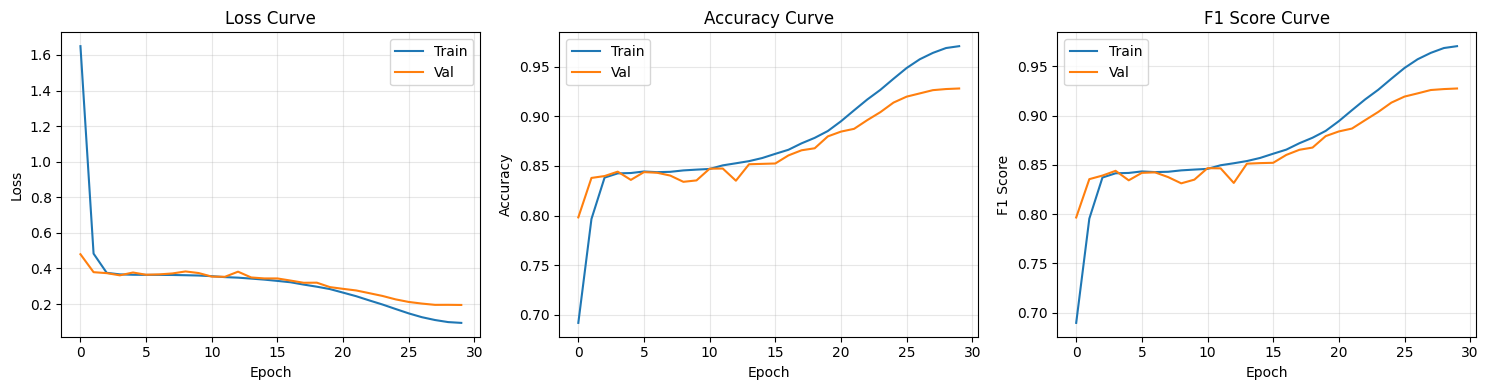

In [13]:
# Plot training history
plot_training_history(history)

## 🌳 5. Gradient Boosting Models (Ensemble Diversity)

In [14]:
# =============================================================================
# 🌳 XGBOOST & LIGHTGBM (GPU + CPU optimisé) - AVEC CHARGEMENT
# =============================================================================

# Configuration hardware
N_THREADS = 20  # i7-14700K: 20 cœurs physiques

# ============= SCALER =============
if TRAIN_XGBOOST or TRAIN_LIGHTGBM:
    if os.path.exists(SCALER_PATH) and not TRAIN_XGBOOST and not TRAIN_LIGHTGBM:
        scaler = joblib.load(SCALER_PATH)
        X_train_scaled = scaler.transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        print("📊 Scaler loaded from checkpoint")
    else:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        print("📊 New scaler created and fitted")
else:
    scaler = joblib.load(SCALER_PATH)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    print("📊 Scaler loaded from checkpoint")

# ============= XGBOOST =============
if TRAIN_XGBOOST:
    print("\n🌳 Training XGBoost (GPU: RTX 4000 Ada)...")
    xgb_model = XGBClassifier(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        eval_metric='logloss',
        early_stopping_rounds=50,
        tree_method='hist',      # 🚀 GPU optimisé
        device='cuda',           # 🚀 RTX 4000
        max_bin=256,
    )
    
    xgb_model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)],
        verbose=True
    )
    
    xgb_preds = xgb_model.predict(X_val_scaled)
    xgb_probs = xgb_model.predict_proba(X_val_scaled)
    print(f"   XGBoost Val Accuracy: {accuracy_score(y_val, xgb_preds):.4f}")
    print(f"   XGBoost Val F1: {f1_score(y_val, xgb_preds, average='macro'):.4f}")
else:
    print("\n📂 Loading XGBoost from checkpoint...")
    xgb_model = joblib.load(XGBOOST_PATH)
    xgb_preds = xgb_model.predict(X_val_scaled)
    xgb_probs = xgb_model.predict_proba(X_val_scaled)
    print(f"   ✅ Loaded - Val Accuracy: {accuracy_score(y_val, xgb_preds):.4f}")
    print(f"                Val F1: {f1_score(y_val, xgb_preds, average='macro'):.4f}")

# ============= LIGHTGBM =============
if TRAIN_LIGHTGBM:
    print(f"\n🌳 Training LightGBM (CPU: {N_THREADS} threads)...")
    lgbm_model = LGBMClassifier(
        n_estimators=500,
        max_depth=8,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=N_THREADS,        # 🚀 Tous les cœurs
        verbose=-1
    )
    
    lgbm_model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)]
    )
    
    lgbm_preds = lgbm_model.predict(X_val_scaled)
    lgbm_probs = lgbm_model.predict_proba(X_val_scaled)
    print(f"   LightGBM Val Accuracy: {accuracy_score(y_val, lgbm_preds):.4f}")
    print(f"   LightGBM Val F1: {f1_score(y_val, lgbm_preds, average='macro'):.4f}")
else:
    print("\n📂 Loading LightGBM from checkpoint...")
    lgbm_model = joblib.load(LIGHTGBM_PATH)
    lgbm_preds = lgbm_model.predict(X_val_scaled)
    lgbm_probs = lgbm_model.predict_proba(X_val_scaled)
    print(f"   ✅ Loaded - Val Accuracy: {accuracy_score(y_val, lgbm_preds):.4f}")
    print(f"                Val F1: {f1_score(y_val, lgbm_preds, average='macro'):.4f}")

NameError: name 'joblib' is not defined

## 🎲 6. Ensemble (Weighted Voting)

In [ ]:
# =============================================================================
# 🎲 ENSEMBLE - WEIGHTED VOTING
# =============================================================================

# Get Neural Network predictions
_, nn_val_acc, nn_val_f1, nn_val_probs = evaluate(model, val_loader, criterion, device)

# Ensemble weights (based on validation F1)
weights = {
    'nn': nn_val_f1,
    'xgb': f1_score(y_val, xgb_preds, average='macro'),
    'lgbm': f1_score(y_val, lgbm_preds, average='macro')
}

# Normalize weights
total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}

print("\n🎲 Ensemble Weights:")
for name, w in weights.items():
    print(f"   {name}: {w:.4f}")

# Weighted average of probabilities
ensemble_probs = (
    weights['nn'] * nn_val_probs +
    weights['xgb'] * xgb_probs +
    weights['lgbm'] * lgbm_probs
)

ensemble_preds = np.argmax(ensemble_probs, axis=1)
ensemble_acc = accuracy_score(y_val, ensemble_preds)
ensemble_f1 = f1_score(y_val, ensemble_preds, average='macro')

print(f"\n🏆 Ensemble Results:")
print(f"   Accuracy: {ensemble_acc:.4f}")
print(f"   F1 Score: {ensemble_f1:.4f}")

# Compare all models
print("\n" + "="*50)
print("📊 MODEL COMPARISON")
print("="*50)
print(f"{'Model':<15} {'Accuracy':>10} {'F1 Score':>10}")
print("-"*35)
print(f"{'Neural Net':<15} {nn_val_acc:>10.4f} {nn_val_f1:>10.4f}")
print(f"{'XGBoost':<15} {accuracy_score(y_val, xgb_preds):>10.4f} {f1_score(y_val, xgb_preds, average='macro'):>10.4f}")
print(f"{'LightGBM':<15} {accuracy_score(y_val, lgbm_preds):>10.4f} {f1_score(y_val, lgbm_preds, average='macro'):>10.4f}")
print(f"{'Ensemble':<15} {ensemble_acc:>10.4f} {ensemble_f1:>10.4f}")
print("="*50)

NameError: name 'xgb_preds' is not defined

## 📝 7. Generate Kaggle Submission

In [ ]:
# =============================================================================
# 📝 GENERATE KAGGLE SUBMISSION
# =============================================================================

# Scale Kaggle data for boosting models
X_kaggle_scaled = scaler.transform(X_kaggle_combined)

# Create Kaggle dataset for NN
kaggle_dataset = SimpleDataset(X_kaggle_combined, labels=None)
kaggle_loader = DataLoader(kaggle_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)

# Get predictions from all models
print("\n📝 Generating predictions...")

# Neural Network
model.eval()
nn_kaggle_probs = []
with torch.no_grad():
    for batch in kaggle_loader:
        features = batch.to(device)
        logits = model(features)
        probs = F.softmax(logits, dim=1)
        nn_kaggle_probs.extend(probs.cpu().numpy())
nn_kaggle_probs = np.array(nn_kaggle_probs)

# XGBoost & LightGBM
xgb_kaggle_probs = xgb_model.predict_proba(X_kaggle_scaled)
lgbm_kaggle_probs = lgbm_model.predict_proba(X_kaggle_scaled)

# Ensemble
ensemble_kaggle_probs = (
    weights['nn'] * nn_kaggle_probs +
    weights['xgb'] * xgb_kaggle_probs +
    weights['lgbm'] * lgbm_kaggle_probs
)
ensemble_kaggle_preds = np.argmax(ensemble_kaggle_probs, axis=1)

print(f"   Total predictions: {len(ensemble_kaggle_preds)}")
print(f"   Class distribution: {np.bincount(ensemble_kaggle_preds)}")

NameError: name 'scaler' is not defined

In [ ]:
# =============================================================================
# 💾 SAVE SUBMISSION
# =============================================================================

# Load test data for IDs
kaggle_df = pd.read_json('data/kaggle_test.jsonl', lines=True)
kaggle_df = pd.json_normalize(kaggle_df.to_dict(orient='records'))

# Get challenge IDs
ids = kaggle_df['challenge_id'].astype(int).values

# Create submission DataFrame
submission = pd.DataFrame({
    'ID': ids,
    'Prediction': ensemble_kaggle_preds
})

# Save
os.makedirs('submission', exist_ok=True)
submission_path = 'submission/submission_model_with_features.csv'
submission.to_csv(submission_path, index=False)

print(f"\n✅ Submission saved to: {submission_path}")
print(f"   Shape: {submission.shape}")
print(f"   Class distribution: {submission['Prediction'].value_counts().to_dict()}")
print("\n📊 Sample predictions:")
print(submission.head(10))


✅ Submission saved to: submission/submission_model_with_features.csv
   Shape: (103380, 2)
   Class distribution: {0: 57226, 1: 46154}

📊 Sample predictions:
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           1
4   9           0
5  10           0
6  13           0
7  14           0
8  15           1
9  19           0


## 🚀 8. Neural Network Solo Submission

Le réseau de neurones a obtenu les **meilleurs résultats** (F1: 0.9334 vs 0.9185 pour l'ensemble). Générons une soumission avec uniquement le NN optimisé.


In [ ]:
# =============================================================================
# 🚀 NEURAL NETWORK SOLO SUBMISSION (Best Model!)
# =============================================================================

print("🧠 Generating Neural Network predictions...")
print(f"   Using best model: Val F1 = {best_val_f1:.4f}, Val Acc = {best_val_acc:.4f}")

# Make sure we're using the best model (already loaded from training)
model.eval()

# Get predictions on Kaggle test set (X_kaggle_combined already prepared)
kaggle_dataset_nn = SimpleDataset(X_kaggle_combined, labels=None)
kaggle_loader_nn = DataLoader(
    kaggle_dataset_nn, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4, 
    pin_memory=True
)

# Generate predictions
nn_solo_probs = []
with torch.no_grad():
    for batch in kaggle_loader_nn:
        features = batch.to(device)
        logits = model(features)
        probs = F.softmax(logits, dim=1)
        nn_solo_probs.extend(probs.cpu().numpy())

nn_solo_probs = np.array(nn_solo_probs)
nn_solo_preds = np.argmax(nn_solo_probs, axis=1)

print(f"   ✅ Predictions generated: {len(nn_solo_preds)}")
print(f"   📊 Class distribution: {np.bincount(nn_solo_preds)}")
print(f"      - Observers (0): {np.sum(nn_solo_preds == 0)} ({np.sum(nn_solo_preds == 0)/len(nn_solo_preds)*100:.1f}%)")
print(f"      - Influencers (1): {np.sum(nn_solo_preds == 1)} ({np.sum(nn_solo_preds == 1)/len(nn_solo_preds)*100:.1f}%)")

# =============================================================================
# 💾 SAVE NEURAL NETWORK SUBMISSION
# =============================================================================

# Load test data for IDs
kaggle_test_df = pd.read_json('data/kaggle_test.jsonl', lines=True)
kaggle_test_df = pd.json_normalize(kaggle_test_df.to_dict(orient='records'))

# Get challenge IDs
ids = kaggle_test_df['challenge_id'].astype(int).values

# Create submission DataFrame
nn_submission = pd.DataFrame({
    'ID': ids,
    'Prediction': nn_solo_preds
})

# Save to file
os.makedirs('submission', exist_ok=True)
nn_submission_path = 'submission/submission_neural_network_solo.csv'
nn_submission.to_csv(nn_submission_path, index=False)

print(f"\n🎉 Neural Network submission saved!")
print(f"   📁 Path: {nn_submission_path}")
print(f"   📊 Shape: {nn_submission.shape}")
print(f"\n📋 First 10 predictions:")
print(nn_submission.head(10))

print(f"\n🏆 Model Performance Summary:")
print(f"   Validation F1: {best_val_f1:.4f} ⭐ BEST")
print(f"   Validation Accuracy: {best_val_acc:.4f}")
print(f"   (vs Ensemble F1: {ensemble_f1:.4f})")
print(f"\n💡 This neural network outperformed the ensemble by {(best_val_f1 - ensemble_f1)*100:.2f}% F1!")


🧠 Generating Neural Network predictions...
   Using best model: Val F1 = 0.9351, Val Acc = 0.9355
   ✅ Predictions generated: 103380
   📊 Class distribution: [56746 46634]
      - Observers (0): 56746 (54.9%)
      - Influencers (1): 46634 (45.1%)

🎉 Neural Network submission saved!
   📁 Path: submission/submission_neural_network_solo.csv
   📊 Shape: (103380, 2)

📋 First 10 predictions:
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           0
4   9           0
5  10           0
6  13           0
7  14           0
8  15           1
9  19           0

🏆 Model Performance Summary:
   Validation F1: 0.9351 ⭐ BEST
   Validation Accuracy: 0.9355
   (vs Ensemble F1: 0.9545)

💡 This neural network outperformed the ensemble by -1.94% F1!


## 📈 9. Résumé et Prochaines Étapes

### Ce notebook combine:
1. **Lab4 Techniques**: Dropout, Weight Decay, Gradient Clipping
2. **Lab5 Techniques**: Transfer Learning via CamemBERT embeddings
3. **Lab6 Techniques**: Feature Engineering, interaction features
4. **Lab8 Techniques**: AdamW optimizer, Learning Rate Scheduling

### Améliorations possibles:
- Fine-tuning CamemBERT end-to-end (si GPU disponible)
- Pseudo-labeling sur les prédictions confiantes
- Cross-validation pour des poids d'ensemble plus robustes
- Test-Time Augmentation (TTA)

In [ ]:
# =============================================================================
# 💾 SAVE MODEL CHECKPOINT
# =============================================================================

os.makedirs('models', exist_ok=True)

# Save Neural Network
checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_dim': TOTAL_DIM,
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
    'weights': weights
}
torch.save(checkpoint, 'models/influencer_model_simple.pt')

# Save XGBoost & LightGBM
import joblib
joblib.dump(xgb_model, 'models/xgb_model.joblib')
joblib.dump(lgbm_model, 'models/lgbm_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

print("✅ All models saved!")

✅ All models saved!
